<a href="https://colab.research.google.com/github/bakdaulet-ds/git-demo/blob/main/Linear_Regression_Lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [40]:
import numpy as np
import matplotlib.pyplot as plt

X = np.array([30, 50, 70, 90, 110])   # размер в м²
y = np.array([100000, 150000, 200000, 260000, 300000])  # цена в $

X_mean = np.mean(X)
X_std = np.std(X)
X_norm = (X - X_mean) / X_std
print(X_norm)

[-1.41421356 -0.70710678  0.          0.70710678  1.41421356]


In [41]:
def predict(X, theta0, theta1):
    return theta0 + theta1 * X

def compute_cost(X, y, theta0, theta1):
    m = len(y)
    predictions = predict(X, theta0, theta1)
    cost = (1 / (2 * m)) * np.sum((predictions - y) ** 2)
    return cost

In [42]:
def gradient_descent(X, y, theta0, theta1, alpha, iterations):
    m = len(y)
    cost_history = []

    for _ in range(iterations):
        predictions = predict(X, theta0, theta1)

        grad0 = (1 / m) * np.sum(predictions - y)
        grad1 = (1 / m) * np.sum((predictions - y) * X)

        theta0 -= alpha * grad0
        theta1 -= alpha * grad1

        cost = compute_cost(X, y, theta0, theta1)
        cost_history.append(cost)

    return theta0, theta1, cost_history

In [43]:
alpha = 0.1
iterations = 1000

theta0 = 0
theta1 = 0

theta0_opt, theta1_opt, cost_hist = gradient_descent(X_norm, y, theta0, theta1, alpha, iterations)

theta0_orig = theta0_opt - theta1_opt * X_mean / X_std
theta1_orig = theta1_opt / X_std

In [44]:
new_size = 85
predicted_price = theta0_orig + theta1_orig * new_size
print(f"\nПредсказанная цена для дома {new_size} м²: ${predicted_price:.2f}")


Предсказанная цена для дома 85 м²: $240250.00


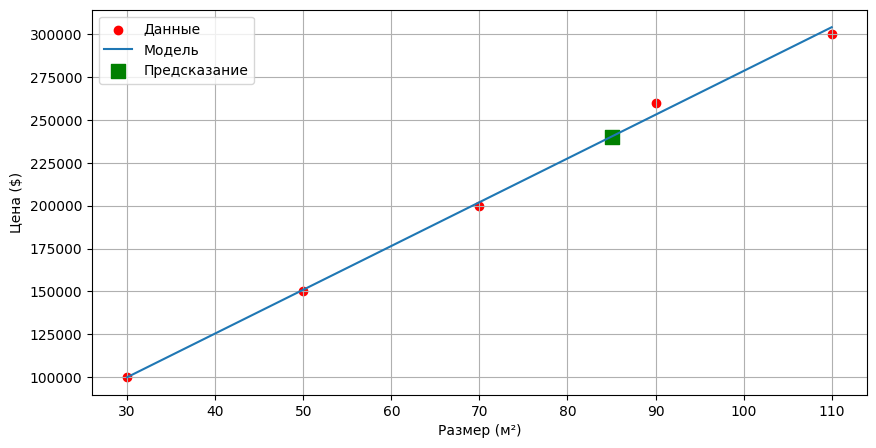

In [45]:
plt.figure(figsize=(10, 5))
plt.scatter(X, y, color='red', label='Данные')
plt.plot(x_line, y_line, label='Модель')
plt.scatter(new_size, predicted_price, color='green', s=100, marker='s', label='Предсказание')
plt.xlabel('Размер (м²)')
plt.ylabel('Цена ($)')
plt.legend()
plt.grid(True)